Inventar un set de datos de por lo menos dos variables.
i) Graficar y analizar la correlación que puede existir entre los datos. Utilizar
algún coeficiente de correlación (Pearson por ejemplo).

El coeficiente de correlacion es:  0.9191621592252626


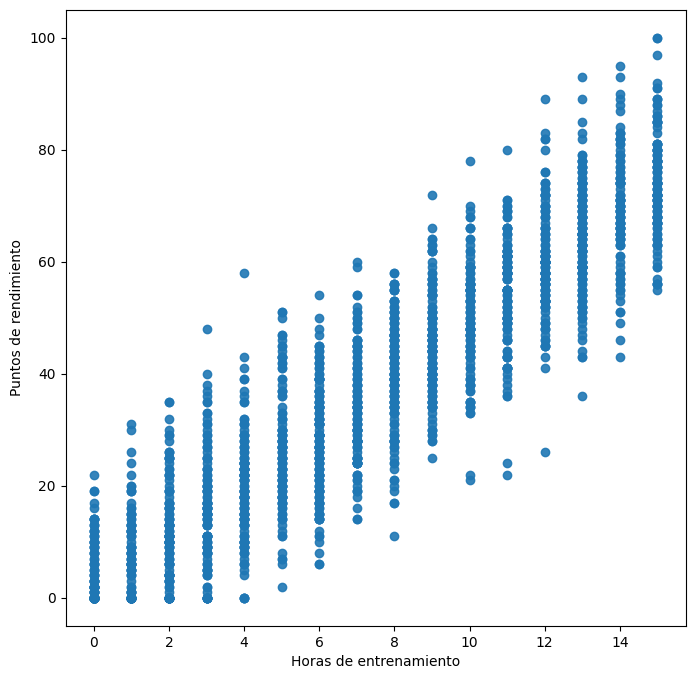

Como conclusion podemos tener que el coeficiente de correlacion entre entre Horas de entrenamiento y rendimiento, estan proximas a 1 

por lo que se puede concluir que existe una fuerte asociacion lineal POSITIVA entre ambas variables, lo que signifia que entre mas horas de entrenamiento haya, mayor cantidad de puntos de rendimiento habra



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(pd.read_csv('dataset_entrenamiento_rendimiento.csv', sep=','))

correlacion = df["Horas_Entrenamiento"].corr(df["Rendimiento_Puntos"], method="pearson")
print("El coeficiente de correlacion es: ", correlacion)
plt.figure(figsize=(8,8))
plt.scatter(df["Horas_Entrenamiento"], df["Rendimiento_Puntos"], alpha=0.9)
plt.xlabel('Horas de entrenamiento')
plt.ylabel('Puntos de rendimiento')
plt.show()


print("Como conclusion podemos tener que el coeficiente de correlacion entre entre Horas de entrenamiento y rendimiento, estan proximas a 1 \n")

print("por lo que se puede concluir que existe una fuerte asociacion lineal POSITIVA entre ambas variables, lo que signifia que entre mas horas de entrenamiento haya, mayor cantidad de puntos de rendimiento habra\n")

Como conclusion podemos tener que el coeficiente de correlacion entre entre Horas de entrenamiento y rendimiento, estan proximas a 1 
por lo que se puede concluir que existe una fuerte asociacion lineal POSITIVA entre ambas variables, lo que significa que entre mas horas de entrenamiento haya, mayor cantidad de puntos de rendimiento habra.
Ademas como las variables estan muy relacionadas entre si, entonces la performance del modelo se deteriora

ii) ¿Cuál es la diferencia entre varianza y desviación estándar?

Varianza: Es una medida de dispercion, la misma es la media de los desvíos, respecto de la media, al cuadrado. Representa la cantidad total de dispersión o riesgo en el conjunto de datos. Cuanto mayor es su valor, más dispersos están los datos. La misma es la desviacion estandar al cuadrado.

Desviación estándar: Es la raiz cuadrada de la varianza. Representa La dispersión promedio o típica de los datos. Nos dice, en promedio, cuánto se espera que un dato individual se aleje de la media

Ambas representan la desviacion de los datos respecto de la medias, es decir la dispercion de los mismos respecto de la media

INICIO DE PCA

PCA trabaja con la hipotesis que si mas varianza se tiene mayor informacion se tiene, es decir, trabaja con la supocision que varianza=informacion

1-Calcula la matriz X de cov de los
datos
2-Calcula los vectores y valores propios
3-Ordena los vectores propios de
acuerdo a sus valores propios en
orden desc
4-Elige los primeros k vectores propios,
que serán las nuevas k dimensiones
5-Transforma los datos originales de
n-dimensiones en k-dimensiones


PASOS PCA:

1-Estandarizacion de los datos: (x-u)/varianza

La Covarianza es una medida de Asociación Lineal entre dos variables.
2-Encontrar la matriz de covarianza, la diagonal representa la varianza de los datos.

3-Eigenvectors y eigenvalor: 
Eigenvectors: Nos dicen la direccion del vector
eigenvalor(varianza explicada): Baasicamente, muesrtra que tanta varianza es explicada por ese componente principal, la misma es la magnitud de el vector
AMBOS VECTORES SON LOS EJES DONDE VAMOS A REPRESENTAR NUESTROS DATOS

4-Proyeccion de los datos: Una vez q tenemos nuestros ejes nos dedicamos a realizar la proyeccion de los mismos hacia donde indican los vectores
¿Por qué es importante estandarizar las variables antes de aplicar PCA?

1) ¿Por qué es importante estandarizar las variables antes de aplicar PCA?
Estandarizar las variables antes de aplicar el Análisis de Componentes Principales (PCA) es crucial porque evita que las variables con una escala o varianza naturalmente mayor dominen la creación de las componentes. Ejemplo:
    Dominio de la Escala: Una variable con una magnitud naturalmente grande (por ejemplo, el "Salario" medido en millones de pesos) tendrá una varianza mucho mayor que una variable con una magnitud pequeña (por ejemplo, la "Edad" medida en años), incluso si ambas son igualmente informativas.
    Resultados Sesgados: PCA interpretará falsamente que la variable con la escala más grande es la más importante y creará Componentes Principales que están casi totalmente definidas por esa variable, ignorando la información contenida en las variables de menor escala.

2) ¿Qué representa un valor propio grande en el contexto de PCA?
Un valor propio grande significa que ese componente principal está capturando mucha de la varianza de los datos. Cuanto más grande, más información explica.

3) Relación entre autovectores y dirección de máxima varianza.
Cada autovector marca una dirección en el espacio de los datos. Esa dirección es la que maximiza la varianza de los datos cuando se proyectan sobre ella. Loy las mismos indican la direccion de la proyeccion, y la proyeccion se hace rotando los ejes, o girandolos

4) Con “n” variables, ¿cuántos componentes principales como máximo puede tener PCA?
Como máximo se pueden obtener n componentes principales, porque no puede haber más dimensiones nuevas que las originales. Por ejemplo, si se intenta hacer una reduccion de dimensionalidad, si se tiene 1 variable, al aplicar PCA, se va a tener como resultado 1 variable( en ese caso seria innecesario)

5) ¿Qué dimensión tendrán los componentes principales?
Cada componente principal tiene la misma cantidad de observaciones que el dataset original, pero con menos columnas (las columnas corresponden a los componentes seleccionados), las columnas representan las variables originales

6) Definir la varianza explicada y la proporción de varianza explicada.
La varianza explicada o el eigenvalue, indica cuanta varianza es capturada por esa componente en especifico. La proporcion de varianza explicada muestra cuanta varianza es explicada por la componente principal, es decir se divide al eigenvalue por la sumatoria de todos los eigenvalues

In [3]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. Seleccionar las variables numéricas
X = df[["Horas_Entrenamiento", "Rendimiento_Puntos"]]

# 3. Estandarizar las variables
scaler = StandardScaler()
X_standar = scaler.fit_transform(X)


In [10]:
#comienzo aplicando PCA
pca = PCA()
X_pca = pca.fit_transform(X_standar)

print("Varianza explicada por cada componente:", pca.explained_variance_)
print("Proporción de varianza explicada:", pca.explained_variance_ratio_)

#como la varianza explicada es mayor a 1 y proximo a 2, es decir captura la mayor parte de la informacion, ya que se tiene que la mayor varianza de cada variable es 1
# pero como se utilizan 2 variables, entonces la mayor varianza es 2

#La primera componente principal explica la mayor parte de la varianza,
#lo cual es esperable porque las dos variables están altamente correlacionadas.

Varianza explicada por cada componente: [1.92012222 0.08087828]
Proporción de varianza explicada: [0.95958108 0.04041892]


In [ ]:
X_proyeccion = X_pca[:, 0].reshape(-1, 1)  # matriz proyección con 1 componente
print("\nMatriz de proyección")
print(X_proyeccion)



Matriz de proyección (primeros 5 registros):
[[-1.05719608]
 [ 2.23903434]
 [-0.18150274]
 ...
 [-1.55880033]
 [-1.83769919]
 [ 2.35705887]]


La matriz proyección son las nuevas coordenadas en el espacio de PCA.

Para volver a los datos originales, se usa pca.inverse_transform().

Si se conservaron menos componentes que las variables originales, la reconstrucción es una aproximación.